In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully.")
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")


Libraries loaded successfully.
pandas version: 2.3.3
numpy version: 2.3.4


## 1. Load M2 Depot-Level Summary Data

In [92]:
def load_m2_sheet(path, sheet):
    """
    Parse a product sheet from the APD M2 summary workbook.
    Each row represents one day of depot-level operations.
    Returns a cleaned DataFrame with typed columns.
    """
    df = pd.read_excel(path, sheet_name=sheet, header=None)
    data = df.iloc[2:].copy()
    data.columns = range(len(data.columns))

    result = pd.DataFrame()
    result['Date']             = pd.to_datetime(data[0],  errors='coerce')
    result['Opening_Stock']    = pd.to_numeric(data[1],   errors='coerce')
    result['Total_Receipts']   = pd.to_numeric(data[10],  errors='coerce')
    result['Total_Deliveries'] = pd.to_numeric(data[16],  errors='coerce')
    result['Book_Balance']     = pd.to_numeric(data[17],  errors='coerce')
    result['Closing_Stock']    = pd.to_numeric(data[18],  errors='coerce')
    result['Loss_Gain']        = pd.to_numeric(data[19],  errors='coerce')
    result['LG_Pct']           = pd.to_numeric(data[20],  errors='coerce')

    result = result.dropna(subset=['Date', 'Loss_Gain'])
    result = result[result['Date'].dt.year == 2025].reset_index(drop=True)
    return result

M2_PATH = r'C:\Users\6USER\Desktop\D2 REPORT 2025\M2 REPORTS-2025- (@ 20)APD DEPOTS.xlsx'

ago = load_m2_sheet(M2_PATH, 'APD AGO 2025')
pms = load_m2_sheet(M2_PATH, 'APD PMS 2025')

print(f"AGO: {len(ago)} records | PMS: {len(pms)} records")
print(f"Date range AGO: {ago['Date'].min().date()} to {ago['Date'].max().date()}")
print(f"Date range PMS: {pms['Date'].min().date()} to {pms['Date'].max().date()}")

ago.to_csv(r'C:\Users\6USER\Desktop\D2 REPORT 2025\ago_m2.csv', index=False)
pms.to_csv(r'C:\Users\6USER\Desktop\D2 REPORT 2025\pms_m2.csv', index=False)
print("Saved ago_m2.csv and pms_m2.csv")

AGO: 365 records | PMS: 365 records
Date range AGO: 2025-01-01 to 2025-12-31
Date range PMS: 2025-01-01 to 2025-12-31
Saved ago_m2.csv and pms_m2.csv


## 2. M2 Dataset Overview

In [93]:
for product, df in [('AGO', ago), ('PMS', pms)]:
    if len(df) == 0:
        print(f"{product}: No data loaded.")
        continue
    print(f"\n{'='*55}")
    print(f"  {product} — M2 Daily Summary")
    print(f"{'='*55}")
    print(f"Records       : {len(df)}")
    print(f"Date range    : {df['Date'].min().date()} to {df['Date'].max().date()}")
    print(f"Loss days     : {(df['Loss_Gain']<0).sum()} ({(df['Loss_Gain']<0).mean()*100:.1f}%)")
    print(f"Gain days     : {(df['Loss_Gain']>0).sum()} ({(df['Loss_Gain']>0).mean()*100:.1f}%)")
    print(f"Zero days     : {(df['Loss_Gain']==0).sum()} ({(df['Loss_Gain']==0).mean()*100:.1f}%)")
    print(f"Missing values: {df.isnull().sum().sum()}")
    print(f"\nLoss/Gain Statistics (litres):")
    print(df['Loss_Gain'].describe().round(2))



  AGO — M2 Daily Summary
Records       : 365
Date range    : 2025-01-01 to 2025-12-31
Loss days     : 75 (20.5%)
Gain days     : 193 (52.9%)
Zero days     : 97 (26.6%)
Missing values: 0

Loss/Gain Statistics (litres):
count      365.00
mean      5021.78
std      11930.64
min     -37758.76
25%          0.00
50%        527.16
75%       7665.26
max      87910.45
Name: Loss_Gain, dtype: float64

  PMS — M2 Daily Summary
Records       : 365
Date range    : 2025-01-01 to 2025-12-31
Loss days     : 112 (30.7%)
Gain days     : 153 (41.9%)
Zero days     : 100 (27.4%)
Missing values: 0

Loss/Gain Statistics (litres):
count       365.00
mean       3858.92
std       16288.51
min      -41939.09
25%       -1186.65
50%           0.00
75%        4981.11
max      175373.27
Name: Loss_Gain, dtype: float64


## 3. Loss/Gain Distribution Visualisation

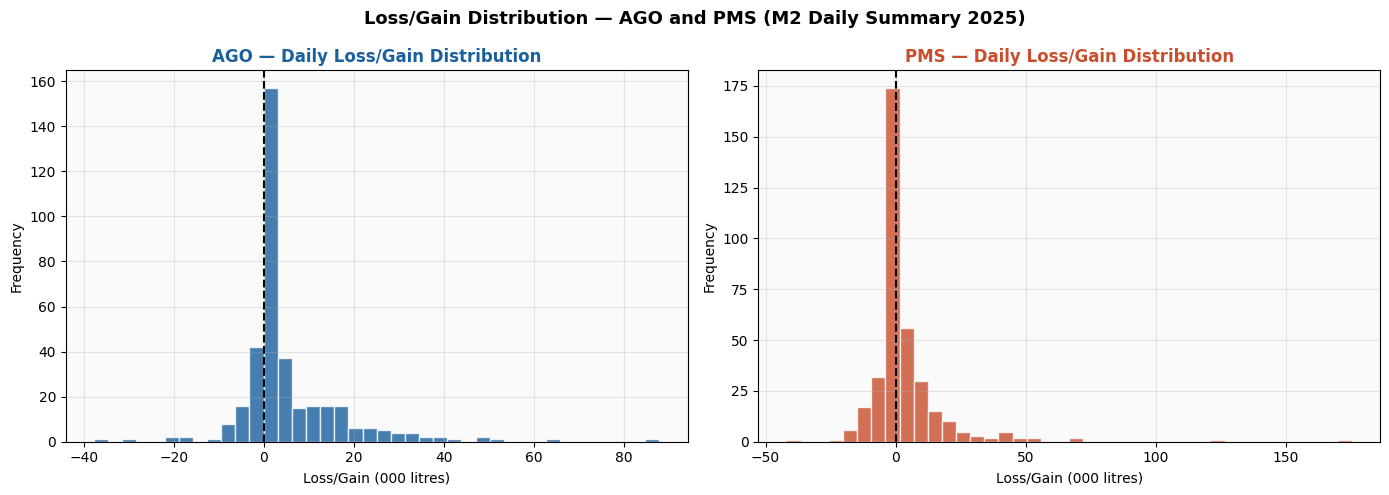

Figure saved.


In [94]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Loss/Gain Distribution — AGO and PMS (M2 Daily Summary 2025)',
             fontsize=13, fontweight='bold')

for ax, (product, df, color) in zip(axes, [('AGO', ago, '#1A5F9E'), ('PMS', pms, '#C94E2D')]):
    if len(df) == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        continue
    ax.hist(df['Loss_Gain']/1000, bins=40, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(0, color='black', lw=1.5, linestyle='--')
    ax.set_title(f'{product} — Daily Loss/Gain Distribution', fontweight='bold', color=color)
    ax.set_xlabel('Loss/Gain (000 litres)')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#FAFAFA')

plt.tight_layout()
plt.savefig(r'C:\Users\6USER\Desktop\D2 REPORT 2025\reports\fig_loss_gain_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")


## 4. Load D2 Tank-Level Data

In [95]:
def safe_num(val):
    """Convert cell value to float. NIL/NaN/empty cells return 0.0."""
    try:
        v = str(val).strip().upper()
        if v in ['NIL', 'NAN', 'NONE', '', 'NIT']:
            return 0.0
        return float(val)
    except:
        return np.nan

def parse_day_sheet(df_raw):
    """
    Extract individual tank records from a single daily D2 sheet.
    Tank rows are identified by Tank ID starting with T-.
    Only Natural Temperature section is used (Temperature > 5 degrees).
    """
    records = []
    for i, row in df_raw.iterrows():
        tank    = str(row[0]).strip()
        product = str(row[1]).strip() if pd.notna(row[1]) else ''
        if not tank.startswith('T-') or product not in ['PMS', 'AGO']:
            continue
        records.append({
            'Tank':           tank,
            'Product':        product,
            'Opening_Dip_mm': safe_num(row[2]),
            'Water_Dip_mm':   safe_num(row[3]),
            'Temperature':    safe_num(row[5]),
            'Opening_Vol':    safe_num(row[6]),
            'Receipt':        safe_num(row[7]),
            'Dispatch':       safe_num(row[8]),
            'Closing_Dip_mm': safe_num(row[10]),
            'Loss_Gain':      safe_num(row[15]),
            'LG_Pct':         safe_num(row[16]),
        })
    return records

# Load from saved CSV if available
import os

BASE = r'C:\Users\6USER\Desktop\D2 REPORT 2025'

D2_FILES = {
    'Feb':    os.path.join(BASE, 'APD-D2 Report-COB - FEBRUARY 2025.xlsx'),
    'March':  os.path.join(BASE, 'APD-D2 Report-COB - MARCH 2025.xlsx'),
    'April':  os.path.join(BASE, 'APD-D2 Report-COB - APRIL 2025 - (1).xlsx'),
    'May':    os.path.join(BASE, 'APD-D2 Report-COB - MAY 2025 (1).xlsx'),
    'June':   os.path.join(BASE, 'APD-D2 Report-COB - JUNE  2025 1.xlsx'),
    'July':   os.path.join(BASE, 'APD-D2 Report-COB -JULY 2025.xlsx'),
    'Aug':    os.path.join(BASE, 'APD-D2 Report-COB -AUG 2025.xlsx'),
    #'Sept_1': os.path.join(BASE, 'APD-D2 Report-COB -Sept  2025 - (1).xlsx'),
    'Sept': os.path.join(BASE, 'APD-D2 Report-COB -Sept 2025.xlsx'),
    'Oct':    os.path.join(BASE, 'APD-D2 Report-COB -Oct 2025.xlsx'),
    # 'Nov_1':  os.path.join(BASE, 'APD-D2 Report-COB -Nov  2025 - (1).xlsx'),
    'Nov':  os.path.join(BASE, 'APD-D2 Report-COB -Nov 2025.xlsx'),
    'Dec':    os.path.join(BASE, 'APD-D2 Report-COB -Dec 2025.xlsx'),
}

all_records = []

for month, path in D2_FILES.items():
    try:
        xl = pd.ExcelFile(path)
        for sheet in xl.sheet_names:
            try:
                date = pd.to_datetime(sheet, format='%d-%b-%y')
            except:
                continue
            df_raw = pd.read_excel(path, sheet_name=sheet, header=None)
            day_records = parse_day_sheet(df_raw)
            for r in day_records:
                r['Date'] = date
                r['Month_Name'] = month
            all_records.extend(day_records)
        print(f"{month}: loaded")
    except Exception as e:
        print(f"{month}: ERROR - {e}")

tank_df = pd.DataFrame(all_records)
tank_df = tank_df[tank_df['Temperature'] > 5]
tank_df = tank_df.sort_values(['Date','Tank','Temperature'], ascending=[True,True,False])
tank_df = tank_df.drop_duplicates(subset=['Date','Tank'], keep='first')
tank_df = tank_df[tank_df['Opening_Dip_mm'] > 0]
tank_df = tank_df.dropna(subset=['Loss_Gain']).reset_index(drop=True)

print(f"\nTotal tank-day records: {len(tank_df)}")
print(f"Date range: {tank_df['Date'].min().date()} to {tank_df['Date'].max().date()}")
print(f"Tanks: {sorted(tank_df['Tank'].unique())}")
print(f"AGO: {(tank_df['Product']=='AGO').sum()} | PMS: {(tank_df['Product']=='PMS').sum()}")

# Save to Desktop so other notebooks can use it
tank_df.to_csv(os.path.join(BASE, 'tank_clean.csv'), index=False)
print("Saved tank_clean.csv")


Feb: loaded
March: loaded
April: loaded
May: loaded
June: loaded
July: loaded
Aug: loaded
Sept: loaded
Oct: loaded
Nov: loaded
Dec: loaded

Total tank-day records: 4264
Date range: 2025-02-01 to 2025-12-31
Tanks: ['T-102', 'T-121', 'T-122', 'T-123', 'T-124', 'T-141', 'T-142', 'T-143', 'T-144', 'T-5801', 'T-5802', 'T-5803', 'T-5804']
AGO: 2296 | PMS: 1968
Saved tank_clean.csv


## 5. Tank-Level Summary Statistics

In [96]:
if len(tank_df) > 0:
    tank_df['Loss_Flag'] = (tank_df['Loss_Gain'] < 0).astype(int)

    print("Tank-Level Summary by Product:")
    print("="*55)
    for product in ['AGO', 'PMS']:
        sub = tank_df[tank_df['Product']==product]
        print(f"\n{product}:")
        print(f"  Records     : {len(sub)}")
        print(f"  Tanks       : {sorted(sub['Tank'].unique())}")
        print(f"  Loss events : {sub['Loss_Flag'].sum()} ({sub['Loss_Flag'].mean()*100:.1f}%)")
        print(f"  Dip range   : {sub['Opening_Dip_mm'].min():.0f} mm to {sub['Opening_Dip_mm'].max():.0f} mm")
        print(f"  Water dip   : {(sub['Water_Dip_mm']>0).sum()} tank-days with water detected")


Tank-Level Summary by Product:

AGO:
  Records     : 2296
  Tanks       : ['T-102', 'T-121', 'T-122', 'T-141', 'T-142', 'T-5802', 'T-5803']
  Loss events : 239 (10.4%)
  Dip range   : 470 mm to 14839 mm
  Water dip   : 747 tank-days with water detected

PMS:
  Records     : 1968
  Tanks       : ['T-123', 'T-124', 'T-143', 'T-144', 'T-5801', 'T-5804']
  Loss events : 271 (13.8%)
  Dip range   : 1173 mm to 14546 mm
  Water dip   : 409 tank-days with water detected
